# Лабораторна робота №4: Інтерактивна обробка сигналів
**Мета:** Створити програму для інтерактивного моделювання гармонічного сигналу з накладеним шумом та його подальшої фільтрації (Low-pass filter).

In [6]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

### 1. Математичні моделі
У цьому блоці реалізовано:
* Генерацію базового масиву шуму (фіксуємо `seed`, щоб форма шуму не стрибала при зміні частоти синусоїди).
* Функцію `harmonic_with_noise` для створення сигналу.
* Функцію `apply_filter` (фільтр Баттерворта) для очищення зашумленого сигналу.

In [7]:
t = np.linspace(0, 10, 1000)
fs = 100.0

np.random.seed(42)
base_noise = np.random.normal(0, 1, len(t))

def harmonic_with_noise(t, amplitude, frequency, phase, noise_mean, noise_covariance):
    clean_signal = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    actual_noise = noise_mean + np.sqrt(noise_covariance) * base_noise
    noisy_signal = clean_signal + actual_noise
    return clean_signal, noisy_signal

def apply_filter(data, cutoff_freq, fs, order=3):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

### 2. Інтерактивний інтерфейс (GUI)
Побудова вікна з графіками, слайдерами для керування параметрами гармоніки та шуму, а також елементами керування (чекбокс видимості та кнопка скидання).

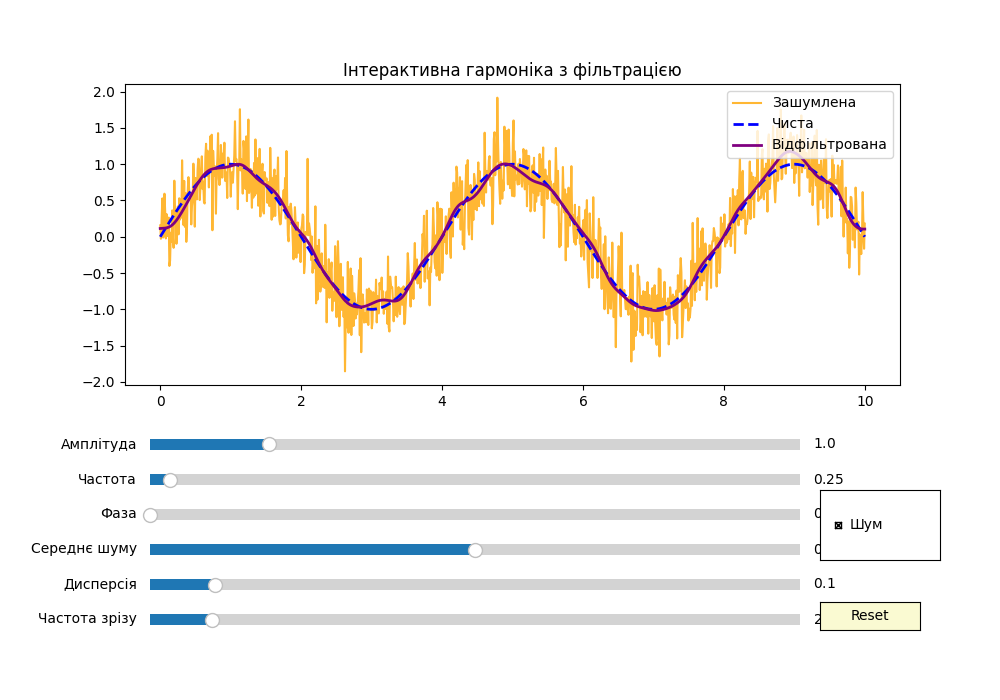

In [8]:
init_amp, init_freq, init_phase = 1.0, 0.25, 0.0
init_noise_mean, init_noise_cov = 0.0, 0.1
init_cutoff = 2.0

clean_init, noisy_init = harmonic_with_noise(t, init_amp, init_freq, init_phase, init_noise_mean, init_noise_cov)
filtered_init = apply_filter(noisy_init, init_cutoff, fs)

fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.45)
ax.set_title("Інтерактивна гармоніка з фільтрацією")

line_noisy, = ax.plot(t, noisy_init, color='orange', label='Зашумлена', alpha=0.8)
line_clean, = ax.plot(t, clean_init, color='blue', linestyle='--', linewidth=2, label='Чиста')
line_filtered, = ax.plot(t, filtered_init, color='purple', linewidth=2, label='Відфільтрована')
ax.legend(loc='upper right')

axcolor = 'lightgoldenrodyellow'
ax_amp = plt.axes([0.15, 0.35, 0.65, 0.03], facecolor=axcolor)
ax_freq = plt.axes([0.15, 0.30, 0.65, 0.03], facecolor=axcolor)
ax_phase = plt.axes([0.15, 0.25, 0.65, 0.03], facecolor=axcolor)
ax_nmean = plt.axes([0.15, 0.20, 0.65, 0.03], facecolor=axcolor)
ax_ncov = plt.axes([0.15, 0.15, 0.65, 0.03], facecolor=axcolor)
ax_cutoff = plt.axes([0.15, 0.10, 0.65, 0.03], facecolor=axcolor)

sl_amp = Slider(ax_amp, 'Амплітуда', 0.1, 5.0, valinit=init_amp)
sl_freq = Slider(ax_freq, 'Частота', 0.1, 5.0, valinit=init_freq)
sl_phase = Slider(ax_phase, 'Фаза', 0.0, 2*np.pi, valinit=init_phase)
sl_nmean = Slider(ax_nmean, 'Середнє шуму', -1.0, 1.0, valinit=init_noise_mean)
sl_ncov = Slider(ax_ncov, 'Дисперсія', 0.0, 1.0, valinit=init_noise_cov)
sl_cutoff = Slider(ax_cutoff, 'Частота зрізу', 0.1, 20.0, valinit=init_cutoff)

ax_check = plt.axes([0.82, 0.2, 0.12, 0.1])
check = CheckButtons(ax_check, ['Шум'], [True])
ax_reset = plt.axes([0.82, 0.1, 0.1, 0.04])
btn_reset = Button(ax_reset, 'Reset', color=axcolor)

def update(val):
    clean, noisy = harmonic_with_noise(t, sl_amp.val, sl_freq.val, sl_phase.val, sl_nmean.val, sl_ncov.val)
    filtered = apply_filter(noisy, sl_cutoff.val, fs)
    line_clean.set_ydata(clean)
    line_noisy.set_ydata(noisy)
    line_filtered.set_ydata(filtered)
    ax.set_ylim(np.min(noisy) - 1, np.max(noisy) + 1)
    fig.canvas.draw_idle()

def toggle_noise(label):
    line_noisy.set_visible(check.get_status()[0])
    fig.canvas.draw_idle()

def reset(event):
    for slider in [sl_amp, sl_freq, sl_phase, sl_nmean, sl_ncov, sl_cutoff]:
        slider.reset()
    if not check.get_status()[0]: check.set_active(0)

for slider in [sl_amp, sl_freq, sl_phase, sl_nmean, sl_ncov, sl_cutoff]:
    slider.on_changed(update)
check.on_clicked(toggle_noise)
btn_reset.on_clicked(reset)

plt.show()